In [1]:
from directional_coupler import DirectionalCoupler2D
from ybranch import YBranch2D
from mmi_2x2 import MMI2x2PowerSplitter2D
from waveguide_crossing import WaveguideCrossing2D
import numpy as np
from utils import plot_fields_2d
from conditioning_masks import make_source_mask
import matplotlib.pyplot as plt

import os
import itertools
import multiprocessing as mp
from pathlib import Path

In [2]:
yb = YBranch2D(
    wg_width_um=0.6,
    wavelength_um=1.6,
    resolution=30,

    # geometry knobs
    l_junction_um=3.5,
    l_bend_um=8,
    h_bend_um=1.2,
    l_out_um=15,

    # optional: override the 13-width junction profile
    # junction_widths_um=[0.45, 0.5, 0.6, 0.8, 1.0, 1.2, 1.3, 1.3, 1.25, 1.1, 1.0, 0.9, 0.9],

    # optional: override cell size if you change lengths a lot
    # cell_x_um=36,
    # cell_y_um=10,
)

mmi = MMI2x2PowerSplitter2D(
    wg_width_um=0.45,
    wavelength_um=1.5,
    resolution=30,
    w_mmi_um=1.2,
    l_mmi_um=8,
    gap_um=0.2,
    s_bend_offset_um=1.0,
    s_bend_length_um=6,
    l_input_um=2.0,
    l_output_um=4.5,
)

cr = WaveguideCrossing2D(
    wg_width_um=0.45,
    wavelength_um=1.55,
    resolution=25,
    dpml=1.0,
    cell_x_um=32.0,
    cell_y_um=6.4,
)


# yb.plot_geometry()
# dc.plot_geometry()
# mmi.plot_geometry()
#dc.plot_geometry()


-----------
Initializing structure...
time for choose_chunkdivision = 0.001863 s
Working in 2D dimensions.
Computational cell is 32 x 8 x 0 with resolution 32
     block, center = (0,0.4755,0)
          size (15,0.6,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (6.38523,6.38523,6.38523)
     block, center = (0,-0.4755,0)
          size (15,0.6,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (6.38523,6.38523,6.38523)
     block, center = (-14.4727,1.97544,0)
          size (0.0574219,0.6,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (6.38523,6.38523,6.38523)
     block, center = (-14.418,1.97499,0)
          size (0.0574219,0.6,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (6.38523,6.38523,6.38523)
     block, center = (-14.3633,1.97409,0)
          size (0.0574219,0.6,1e+20)
          ax

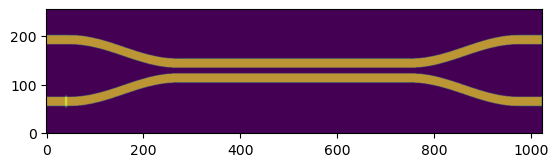

-----------
Initializing structure...
time for choose_chunkdivision = 0.00180006 s
Working in 2D dimensions.
Computational cell is 32 x 8 x 0 with resolution 32
     block, center = (0,0.4755,0)
          size (15,0.6,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (6.38523,6.38523,6.38523)
     block, center = (0,-0.4755,0)
          size (15,0.6,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (6.38523,6.38523,6.38523)
     block, center = (-14.4727,1.97544,0)
          size (0.0574219,0.6,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (6.38523,6.38523,6.38523)
     block, center = (-14.418,1.97499,0)
          size (0.0574219,0.6,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (6.38523,6.38523,6.38523)
     block, center = (-14.3633,1.97409,0)
          size (0.0574219,0.6,1e+20)
          

MPB solved for frequency_1(1.63026,0,0) = 0.679537 after 18 iters
MPB solved for frequency_1(1.544,0,0) = 0.645102 after 7 iters
MPB solved for frequency_1(1.54414,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.54414,0,0) = 0.645161 after 1 iters
on time step 488 (time=7.625), 0.00821019 s/step
on time step 932 (time=14.5625), 0.00901432 s/step
on time step 1336 (time=20.875), 0.00991633 s/step
on time step 1751 (time=27.3594), 0.00965942 s/step
on time step 2175 (time=33.9844), 0.00944317 s/step
on time step 2603 (time=40.6719), 0.00935917 s/step
on time step 3034 (time=47.4062), 0.00929778 s/step
on time step 3478 (time=54.3438), 0.00902793 s/step
on time step 3933 (time=61.4531), 0.00879653 s/step
on time step 4391 (time=68.6094), 0.00873715 s/step
on time step 4835 (time=75.5469), 0.00902749 s/step
on time step 5257 (time=82.1406), 0.00948795 s/step
on time step 5697 (time=89.0156), 0.00910055 s/step
on time step 6148 (time=96.0625), 0.00887821 s/step
on time step 6627 

run 0 finished at t = 289.078125 (18501 timesteps)
MPB solved for frequency_1(1.63026,0,0) = 0.679537 after 18 iters
MPB solved for frequency_1(1.544,0,0) = 0.645102 after 7 iters
MPB solved for frequency_1(1.54414,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.54414,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.544145,-0.000000,0.000000)


MPB solved for frequency_1(1.63026,0,0) = 0.679537 after 18 iters
MPB solved for frequency_1(1.544,0,0) = 0.645102 after 7 iters
MPB solved for frequency_1(1.54414,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.54414,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.544145,-0.000000,0.000000)


MPB solved for frequency_1(1.63026,0,0) = 0.679537 after 18 iters
MPB solved for frequency_1(1.544,0,0) = 0.645102 after 7 iters
MPB solved for frequency_1(1.54414,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.54414,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.544145,-0.000000,0.000000)


MPB solved for frequency_1(1.63026,0,0) = 0.679537 after 18 iters
MPB solved for frequency_1(1.544,0,0) = 0.645102 after 7 iters
MPB solved for frequency_1(1.54414,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.54414,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.544145,-0.000000,0.000000)
=== 2D 2×2 coupler, excitation at port 2 ===
S12 = -0.0009538+0.00345j, |S12|^2 = 1.281e-05
S22 = 0.0009353+0.009399j, |S22|^2 = 8.921e-05
S32 = -0.2858-0.3301j, |S32|^2 = 0.1906
S42 = -0.6677+0.5923j, |S42|^2 = 0.7965
Sum of guided powers Σ|S·2|^2 = 0.9873


In [5]:
dc = DirectionalCoupler2D(
    wg_width_um=0.6,
    gap_um=0.351,
    wg_length_um=15,
    wavelength_um=1.55,
    resolution=32,
    dpml=1,
    pad_y_um=1.0,
    bend_length_um=7,
    bend_n_segments=128,
    lead_extra_gap_um=3,
)

eps, (Lx, Ly) = dc.get_eps_and_cell()
ny, nx = eps.shape

src_mask = make_source_mask(
    input_port=2,
    port_centers_um=dc.get_port_centers_um(),
    y_span_um=dc.get_port_y_span_um(),
    Lx_um=Lx,
    Ly_um=Ly,
    ny=ny,
    nx=nx,
)

plt.imshow(eps, origin="lower")
plt.imshow(src_mask, origin="lower", alpha=0.35)
plt.show()

eps, Ez, Hx, Hy, S, cell = dc.run_sim(input_port=2, decay_tol=1e-6)

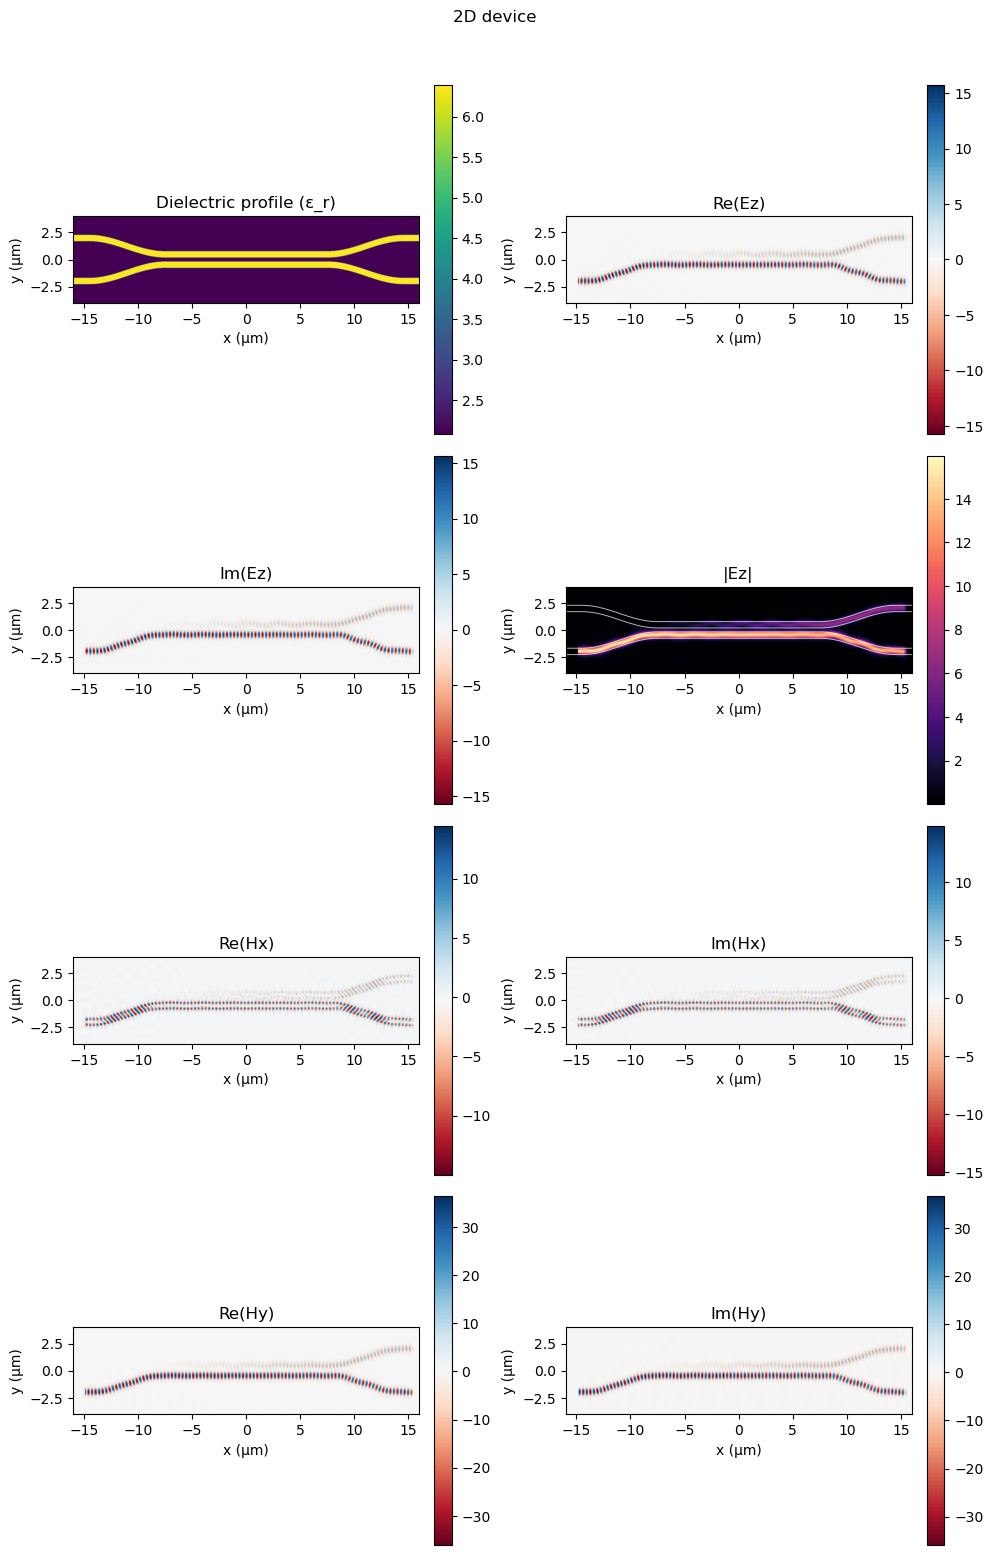

In [3]:
cell_x, cell_y = cell
plot_fields_2d(eps, Ez, Hx_mid=Hx, Hy_mid=Hy, cell_x_um=cell[0], cell_y_um=cell[1], abs_scale="linear")